In [3]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [4]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        # * is p < 0.05
        # ** is p < 0.005
        # *** is p < 0.0005
        # etc.
        text = ''
        p = .05

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

In [6]:
metrics_dir=os.path.join(os.getcwd(),"metrics")
# --- LOAD THE .pkl FILE GENERATED PREVIOUSLY ---
adapt=0
test_ds_b4=False
if test_ds_b4:
    identifier=f"testing_dsb4_adaptable{adapt}" if adapt > 0 else "testing_dsb4"
else:
    identifier=f"30000_1000_100_adaptable{adapt}" if adapt > 0 else "30000_1000_100"
    # identifier="1000_200_median"

dataset_colors={
   "Amigo": "#8E44AD",
   "Dlx": "#E74C3C",
   "Som": "#FFC300",
   "Thy": "#17BECF"
}

In [7]:
filename= f"channel_metrics_by_network_{identifier}.csv"
results_df= pd.read_csv(os.path.join(metrics_dir, filename))
print(f"Results loaded from {os.path.join(metrics_dir, filename)}")
print(results_df.head())

Results loaded from c:\Users\Pc\Documents\Tese\LAVA_SNN_ripples\snnTorch\eval\live_results\metrics\channel_metrics_by_network_30000_1000_100.csv
                   Network                     Dataset  Channel   TP   FP  FN  \
0  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        0  215  786   9   
1  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        1  203  480  21   
2  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        2  183  259  41   
3  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        3  146  112  78   
4  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07        4  142  178  82   

   Precision    Recall        F1  
0   0.214785  0.959821  0.351020  
1   0.297218  0.906250  0.447630  
2   0.414027  0.816964  0.549550  
3   0.565891  0.651786  0.605809  
4   0.443750  0.633929  0.522059  


In [8]:
from matplotlib.patches import Patch


def plot_whiskers_by_dataset(df, metrics=["Precision", "Recall", "F1"], colors=None,back_colors=None,add_overall=True):
    if colors is None:
        colors = {
            "Precision": "royalblue",
            "Recall": "seagreen",
            "F1": "darkorange"
        }
    labels=["Amigo","Dlx","Som","Thy","Overall"]
    df = df.copy()  # avoid modifying original DataFrame

    # Compute and add "Overall" if requested
    if add_overall:
        overall_rows = df[metrics].copy()
        overall_rows["Dataset"] = "Overall"
        df = pd.concat([df, overall_rows], ignore_index=True)

    # Get dataset list and ensure "Overall" is last
    datasets = sorted(df['Dataset'].unique())
    if "Overall" in datasets:
        datasets = [d for d in datasets if d != "Overall"] + ["Overall"]

    width = 1  # Width of each box
    fig, ax = plt.subplots(figsize=(10, 6))

    positions = []
    data = []
    plot_colors = []
    xticks = []
    xtick_labels = []

    for i, dataset in enumerate(datasets):
        base_pos = i * (len(metrics) + 1)  # spacing between groups
        for j, metric in enumerate(metrics):
            vals = df[df['Dataset'] == dataset][metric].dropna().values
            pos = base_pos + j * width
            data.append(vals)
            positions.append(pos)
            plot_colors.append(colors.get(metric, "gray"))

        # X-axis ticks centered on group
        xticks.append(base_pos + (len(metrics) - 1) * width / 2)
        xtick_labels.append(labels[i])

        # Background shading
        if back_colors and labels[i] in back_colors:
            ax.axvspan(base_pos - 0.7, base_pos + len(metrics) * width - 0.3, color=back_colors[labels[i]], alpha=0.2)
        else:
            ax.axvspan(base_pos - 0.7, base_pos + len(metrics) * width - 0.3, color="lightgray", alpha=0.2)

    # Draw boxplots
    for d, p, c in zip(data, positions, plot_colors):
        bplot = ax.boxplot(d, positions=[p], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(c)

    # Aesthetics
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, fontsize=14)
    ax.set_ylabel("Score", fontsize=14)
    ax.set_title("Precision, Recall, and F1 Score - Channels", fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(-1, len(datasets) * (len(metrics) + 1) - 1)
    ax.set_ylim(0, 1)  # Assuming scores are between 0 and 1

    # Clean up
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    # Legend
    # legend_handles = [Patch(facecolor=colors[m], label=m) for m in metrics]
    # ax.legend(handles=legend_handles, fontsize=12, loc='upper left', bbox_to_anchor=(1.01, 0.5))

    plt.tight_layout()
    plt.show()
    return fig, ax

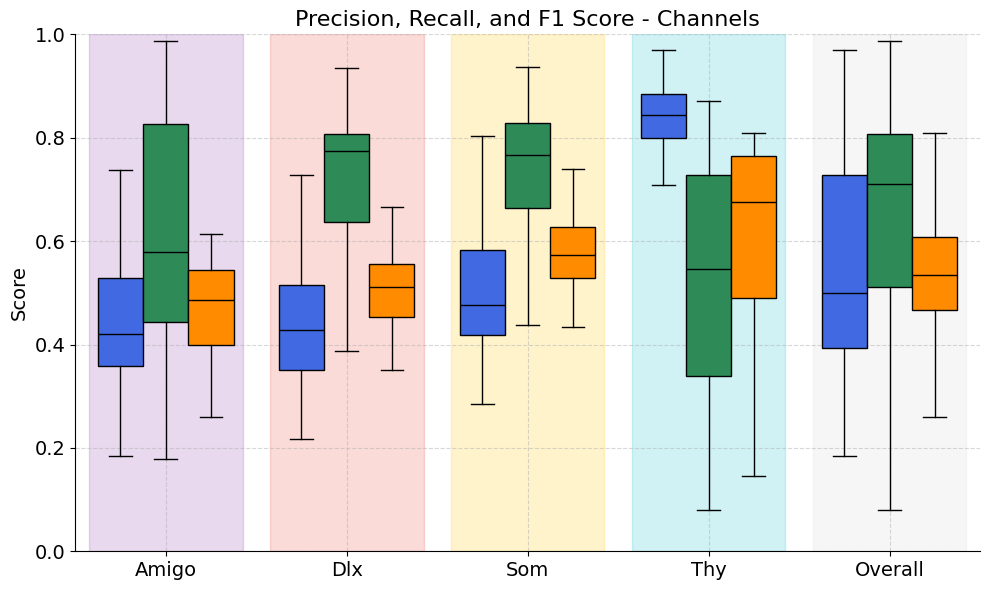

In [11]:
fig,ax=plot_whiskers_by_dataset(results_df,back_colors=dataset_colors)
# Channel-wise, by dataset
# os.makedirs(os.path.join(os.getcwd(),"figures"),exist_ok=True)
# fig.savefig(os.path.join("figures","whiskers_by_channel.png"),bbox_inches="tight",dpi=300)

In [9]:
import pandas as pd

def summarize_metrics_by_dataset_and_network(df, metrics=["Precision", "Recall", "F1"]):
    summary_rows = []

    datasets = sorted(df['Dataset'].unique())

    # Summarize per dataset
    for dataset in datasets:
        subset = df[df['Dataset'] == dataset][metrics]
        row = {"Dataset": dataset}
        for metric in metrics:
            vals = subset[metric].dropna()
            row[f"{metric} Median ± Std"] = f"{vals.median():.2f} ± {vals.std():.2f}"
            row[f"{metric} Mean"] = f"{vals.mean():.2f}"
            row[f"{metric} Peak"] = f"{vals.max():.2f}"
        summary_rows.append(row)

    # Compute mean metrics per network across datasets
    network_means = df.groupby('Network')[metrics].mean()
    overall_row = {"Dataset": "Overall"}

    for metric in metrics:
        all_vals = df[metric].dropna()
        mean = all_vals.mean()
        std = all_vals.std()
        median = all_vals.median()

        # Find network with best average metric across datasets
        best_network = network_means[metric].idxmax()
        best_network_avg = network_means.loc[best_network, metric]

        overall_row[f"{metric} Median ± Std"] = f"{median:.2f} ± {std:.2f}"
        overall_row[f"{metric} Mean"] = f"{mean:.2f}"
        overall_row[f"{metric} Peak"] = f"{best_network_avg:.2f}"

    summary_rows.append(overall_row)

    summary_df = pd.DataFrame(summary_rows)
    return summary_df


In [10]:
import pandas as pd
import numpy as np

def summarize_metrics_by_dataset_and_network(df, metrics=["Precision", "Recall", "F1"]):
    summary_rows = []

    datasets = sorted(df['Dataset'].unique())

    # Summarize per dataset
    for dataset in datasets:
        subset = df[df['Dataset'] == dataset][metrics]
        row = {"Dataset": dataset}
        for metric in metrics:
            vals = subset[metric].dropna()
            row[f"{metric} Median ± Std"] = f"{vals.median():.2f} ± {vals.std():.2f}"
            row[f"{metric} Mean"] = f"{vals.mean():.2f}"
            row[f"{metric} Peak"] = f"{vals.max():.2f}"
        summary_rows.append(row)

    # Compute mean metrics per network across datasets (network average over channels & datasets)
    network_means = df.groupby('Network')[metrics].mean()

    overall_row = {"Dataset": "Overall"}
    best_by_metric = {}  # will hold (best_network, best_network_avg) per metric

    for metric in metrics:
        all_vals = df[metric].dropna()
        mean = all_vals.mean()
        std = all_vals.std()
        median = all_vals.median()

        # For each network, compute per-dataset maxima then average them
        networks = sorted(df['Network'].unique())
        network_peak_scores = {}
        for net in networks:
            per_dataset_maxes = []
            for dataset in datasets:
                vals = df.loc[(df['Network'] == net) & (df['Dataset'] == dataset), metric].dropna().values
                if vals.size > 0:
                    per_dataset_maxes.append(vals.max())
                # if a network has no data for a dataset we simply skip that dataset for this network
            # Use nan if no data at all for this network
            network_peak_scores[net] = np.mean(per_dataset_maxes) if per_dataset_maxes else np.nan

        # pick best network by highest average of per-dataset maxima (ignore NaNs)
        # if all are NaN, best_network will be None
        valid_scores = {k: v for k, v in network_peak_scores.items() if not np.isnan(v)}
        if valid_scores:
            best_network = max(valid_scores, key=lambda k: valid_scores[k])
            best_network_avg = valid_scores[best_network]
            overall_peak_str = f"{best_network_avg:.2f} ({best_network})"
        else:
            best_network = None
            best_network_avg = np.nan
            overall_peak_str = "n/a"

        best_by_metric[metric] = {"best_network": best_network, "best_network_avg": best_network_avg}

        overall_row[f"{metric} Median ± Std"] = f"{median:.2f} ± {std:.2f}"
        overall_row[f"{metric} Mean"] = f"{mean:.2f}"
        overall_row[f"{metric} Peak"] = overall_peak_str

    summary_rows.append(overall_row)

    summary_df = pd.DataFrame(summary_rows)
    return summary_df, best_by_metric


In [11]:
summary_df,best_by_metric=summarize_metrics_by_dataset_and_network(results_df, metrics=["Precision", "Recall", "F1"])
print(best_by_metric)
output_path = f"figures\\summary_channel_wide_{identifier}.xlsx"
summary_df.to_excel(output_path, index=False)

{'Precision': {'best_network': 'dsb4updn_median_200_12b', 'best_network_avg': 0.815400968404659}, 'Recall': {'best_network': 'adapt20_3b', 'best_network_avg': 0.9325236527367967}, 'F1': {'best_network': 'updnb4ds_100_13f', 'best_network_avg': 0.6862934227905458}}


In [12]:
def get_network_means_per_dataset(df, metrics=["Precision", "Recall", "F1"]):
    # Assuming df has columns: Dataset, Network, Channel (optional), metrics...
    # Group by Dataset and Network, average over channels
    grouped = df.groupby(['Dataset', 'Network'])[metrics].mean().reset_index()
    return grouped

def plot_whiskers_by_dataset_network_means(df, metrics=["Precision", "Recall", "F1"], colors=None, back_colors=None, add_overall=True):
    if colors is None:
        colors = {
            "Precision": "royalblue",
            "Recall": "seagreen",
            "F1": "darkorange"
        }
    labels=["Amigo","Dlx","Som","Thy"]

    if add_overall:
        labels.append("Overall")

    # Prepare data: group by Dataset and Network, get network means per dataset
    grouped = get_network_means_per_dataset(df, metrics=metrics)

    # Add "Overall" row if requested: mean across all datasets for each network
    if add_overall:
        overall_means = grouped.groupby('Network')[metrics].mean().reset_index()
        overall_means['Dataset'] = 'Overall'
        grouped = pd.concat([grouped, overall_means], ignore_index=True)

    datasets = sorted(grouped['Dataset'].unique())
    if "Overall" in datasets:
        datasets = [d for d in datasets if d != "Overall"] + ["Overall"]

    width = 1  # width of each box
    fig, ax = plt.subplots(figsize=(10, 6))

    positions = []
    data = []
    plot_colors = []
    xticks = []
    xtick_labels = []

    for i, dataset in enumerate(datasets):
        base_pos = i * (len(metrics) + 1)  # spacing between groups
        for j, metric in enumerate(metrics):
            vals = grouped[grouped['Dataset'] == dataset][metric].dropna().values
            pos = base_pos + j * width
            data.append(vals)
            positions.append(pos)
            plot_colors.append(colors.get(metric, "gray"))

        # X-axis ticks centered on group
        xticks.append(base_pos + (len(metrics) - 1) * width / 2)
        xtick_labels.append(labels[i])

        # Background shading
        if back_colors and labels[i] in back_colors:
            ax.axvspan(base_pos - 0.7, base_pos + len(metrics) * width - 0.3, color=back_colors[labels[i]], alpha=0.2)
        else:
            ax.axvspan(base_pos - 0.7, base_pos + len(metrics) * width - 0.3, color="lightgray", alpha=0.1)

    # Draw boxplots
    for d, p, c in zip(data, positions, plot_colors):
        bplot = ax.boxplot(d, positions=[p], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(c)

    # Aesthetics
    ax.tick_params(axis='y', which='major', labelsize=14)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, fontsize=14)
    ax.set_ylabel("Score", fontsize=14)
    ax.set_title("Precision, Recall, and F1 Score - Dataset Averages", fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(-1, len(datasets) * (len(metrics) + 1) - 1)
    ax.set_ylim(0, 1)  # Assuming scores are between 0 and 1
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    # legend_handles = [Patch(facecolor=colors[m], label=m) for m in metrics]
    # ax.legend(handles=legend_handles, fontsize=12, loc='upper left', bbox_to_anchor=(1.01, 0.5))

    plt.tight_layout()
    plt.show()
    return fig, ax

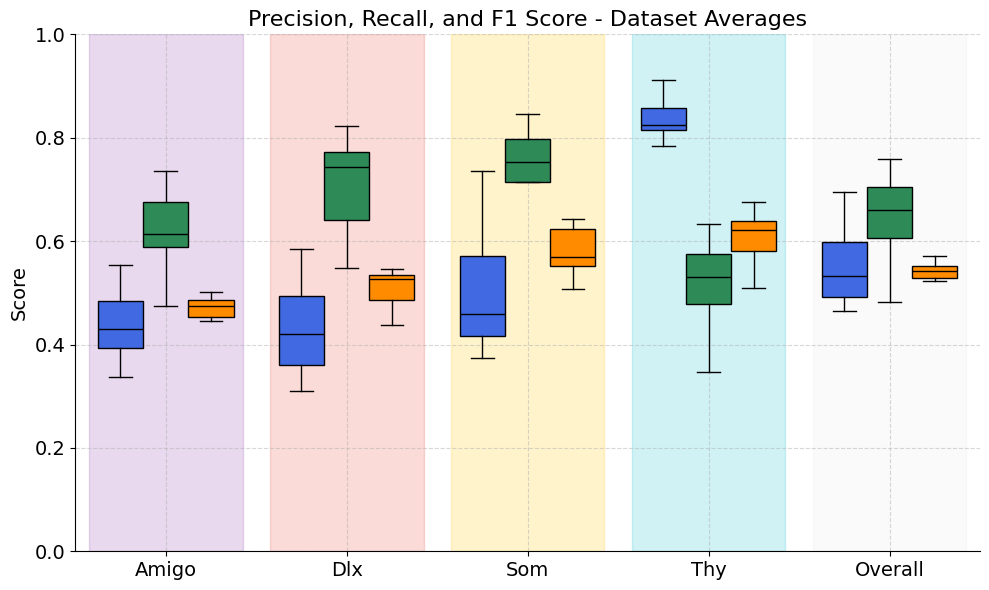

In [13]:
fig,ax=plot_whiskers_by_dataset_network_means(results_df, metrics=["Precision", "Recall", "F1"],back_colors=dataset_colors)
# fig.savefig(os.path.join("figures","whiskers_by_dataset.png"),bbox_inches="tight",dpi=300)

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import itertools
import pandas as pd
from scipy.stats import mannwhitneyu, wilcoxon

def holm_bonferroni(p_values, alpha=0.05):
    """Apply Holm–Bonferroni correction to a list of p-values."""
    m = len(p_values)
    sorted_indices = np.argsort(p_values)
    sorted_pvals = np.array(p_values)[sorted_indices]
    reject = np.zeros(m, dtype=bool)
    adjusted_pvals = np.zeros(m)

    for k, p in enumerate(sorted_pvals):
        threshold = alpha / (m - k)
        if p <= threshold:
            reject[sorted_indices[k]] = True
        adjusted_pvals[sorted_indices[k]] = min(p * (m - k), 1.0)

    return adjusted_pvals, reject

def get_network_means_per_dataset(df, metrics=["Precision", "Recall", "F1"]):
    """Group by Dataset and Network, average over channels."""
    grouped = df.groupby(['Dataset', 'Network'])[metrics].mean().reset_index()
    return grouped

def plot_whiskers_dataset(df, metrics=["Precision", "Recall", "F1"], 
                          group_level="dataset", colors=None, back_colors=None, add_overall=False, stat_test=True,alpha=0.05):
    """
    Plot metrics grouped by dataset, either at dataset-average level or channel-level.
    
    group_level: "dataset" (use dataset averages) or "channel" (raw channel-level values)
    """

    if back_colors is None:
        back_colors = {
            "Precision": "lightblue",
            "Recall": "lightgreen",
            "F1": "lightcoral"
        }
    if colors is None:
        colors={
            "Amigo": "#8E44AD",
            "Dlx": "#E74C3C",
            "Som": "#FFC300",
            "Thy": "#17BECF",
            "Overall": "#726B6BFF"  # Overall color, can be customized
        }
    else:
        colors["Overall"] = "#726B6BFF"

    labels = ["Amigo", "Dlx", "Som", "Thy"]
    if add_overall:
        labels.append("Overall")
    # Prepare data
    if group_level == "dataset":
        grouped = get_network_means_per_dataset(df, metrics=metrics)
    elif group_level == "channel":
        grouped = df.copy()
    else:
        raise ValueError("group_level must be 'dataset' or 'channel'")
    
    # # Add "Overall" depending on group_level
    # if add_overall:
    #     if group_level == "dataset":
    #         # Mean across datasets per network
    #         overall_means = grouped.groupby('Network')[metrics].mean().reset_index()
    #         overall_means['Dataset'] = 'Overall'
    #         grouped = pd.concat([grouped, overall_means], ignore_index=True)
    #     elif group_level == "channel":
    #         # Pool all channels across datasets
    #         overall_dist = grouped.copy()
    #         overall_dist = overall_dist.assign(Dataset="Overall")
    #         grouped = pd.concat([grouped, overall_dist], ignore_index=True)
    if add_overall:
        if group_level == "dataset":
            # Instead of averaging, just pool all rows
            overall_dist = grouped.copy()
            overall_dist['Dataset'] = 'Overall'
            grouped = pd.concat([grouped, overall_dist], ignore_index=True)

    datasets = sorted(grouped['Dataset'].unique())
    if "Overall" in datasets:  # ensure "Overall" is last
        datasets = [d for d in datasets if d != "Overall"] + ["Overall"]

    fig, ax = plt.subplots(figsize=(10, 6))
    width = 0.8
    spacing = 1.5
    positions, data, plot_colors = [], [], []
    xticks, xtick_labels = [], []

    # Collect positions and data
    for i, metric in enumerate(metrics):
        base_pos = i * (len(datasets) + spacing)
        for j, d in enumerate(datasets):
            vals = grouped[grouped['Dataset'] == d][metric].dropna().values
            pos = base_pos + j
            positions.append(pos)
            data.append(vals)
            plot_colors.append(colors.get(labels[j], "gray"))
        xticks.append(base_pos + (len(datasets)-1)/2)
        xtick_labels.append(metric)

        # Background shading
        if back_colors and metric in back_colors:
            ax.axvspan(base_pos - 0.7, base_pos + (len(datasets) + spacing) * width - 0.5,
                       color=back_colors.get(metric, "lightgray"), alpha=0.2)
        else:
            ax.axvspan(base_pos - 0.7, base_pos + (len(datasets) + spacing) * width - 0.3,
                       color="lightgray", alpha=0.1)

    # Draw boxplots
    box_heights = []
    for pos, vals, c in zip(positions, data, plot_colors):
        bplot = ax.boxplot(vals, positions=[pos], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(c)
        box_heights.append(np.max(vals))

    # Statistical tests per metric
    # for i, metric in enumerate(metrics):
    #     group_indices = range(i * len(datasets), (i + 1) * len(datasets))
    #     group_data = [data[k] for k in group_indices]
    #     group_pos = [positions[k] for k in group_indices]
    #     group_heights = [box_heights[k] for k in group_indices]

    #     # Compute pairwise tests
    #     comparisons = list(itertools.combinations(range(len(datasets)), 2))
    #     p_values = []
    #     for idx_a, idx_b in comparisons:
    #         if len(group_data[idx_a]) > 0 and len(group_data[idx_b]) > 0:
    #             _, p = mannwhitneyu(group_data[idx_a], group_data[idx_b], alternative="two-sided")
    #         else:
    #             p = 1.0
    #         p_values.append(p)

    #     # Holm–Bonferroni
    #     adj_pvals, _ = holm_bonferroni(p_values, alpha=alpha)

    #     # Track annotation levels
    #     annotation_levels = np.zeros(len(group_data))
    #     for (idx_a, idx_b), adj_p in zip(comparisons, adj_pvals):
    #         level = max(annotation_levels[idx_a], annotation_levels[idx_b])
    #         heights_for_bracket = [h + 0.04*level for h in group_heights]
    #         if adj_p < alpha:
    #             annotation_levels[idx_a] = annotation_levels[idx_b] = level + 1
    #         barplot_annotate_brackets(idx_a, idx_b, adj_p, group_pos, heights_for_bracket, ax, dh=0.01, barh=0.0)

    # Statistical tests per metric (EXCLUDE "Overall")
    if stat_test:
        for i, metric in enumerate(metrics):
            print(metric)
            group_indices = range(i * len(datasets), (i + 1) * len(datasets))

            # Exclude "Overall" index from all arrays
            valid_indices = [idx for idx, d in enumerate(datasets) if d != "Overall"]
            group_data = [data[i * len(datasets) + idx] for idx in valid_indices]
            group_pos = [positions[i * len(datasets) + idx] for idx in valid_indices]
            group_heights = [box_heights[i * len(datasets) + idx] for idx in valid_indices]

            # Pairwise comparisons only among valid datasets
            comparisons = list(itertools.combinations(range(len(valid_indices)), 2))

            p_values = []
            for idx_a, idx_b in comparisons:
                if len(group_data[idx_a]) > 0 and len(group_data[idx_b]) > 0:
                    #_, p = mannwhitneyu(group_data[idx_a], group_data[idx_b], alternative="two-sided")
                    _, p = wilcoxon(group_data[idx_a], group_data[idx_b])
                else:
                    p = 1.0
                p_values.append(p)

            # Holm–Bonferroni correction
            adj_pvals, _ = holm_bonferroni(p_values, alpha=alpha)

            # Track annotation levels
            annotation_levels = np.zeros(len(group_data))
            for (idx_a, idx_b), adj_p in zip(comparisons, adj_pvals):
                level = max(annotation_levels[idx_a], annotation_levels[idx_b])
                heights_for_bracket = [h + 0.03*level for h in group_heights]
                if metric=="Recall" and idx_a ==0 and idx_b==2:
                    heights_for_bracket = [h + 0.05*level for h in group_heights]  # Adjust height for specific comparison
                if adj_p < alpha:
                    annotation_levels[idx_a] = annotation_levels[idx_b] = level + 1
                    print(f"Comparison between {datasets[valid_indices[idx_a]]} and {datasets[valid_indices[idx_b]]}: p={adj_p:.4f}")
                barplot_annotate_brackets(idx_a, idx_b, adj_p, group_pos, heights_for_bracket, ax, dh=0.01, barh=0.0)


    # Formatting
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, fontsize=14)
    ax.tick_params(axis='y', which='major', labelsize=14)
    ax.set_xlabel("Metric", fontsize=14)
    ax.set_ylabel("Score", fontsize=14)
    title=f"Performance by Dataset (Averaged)" if group_level == "dataset" else "Performance by Dataset (Channel)"
    ax.set_title(title, fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(0, 1.1)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    # Remove spines
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    return fig, ax


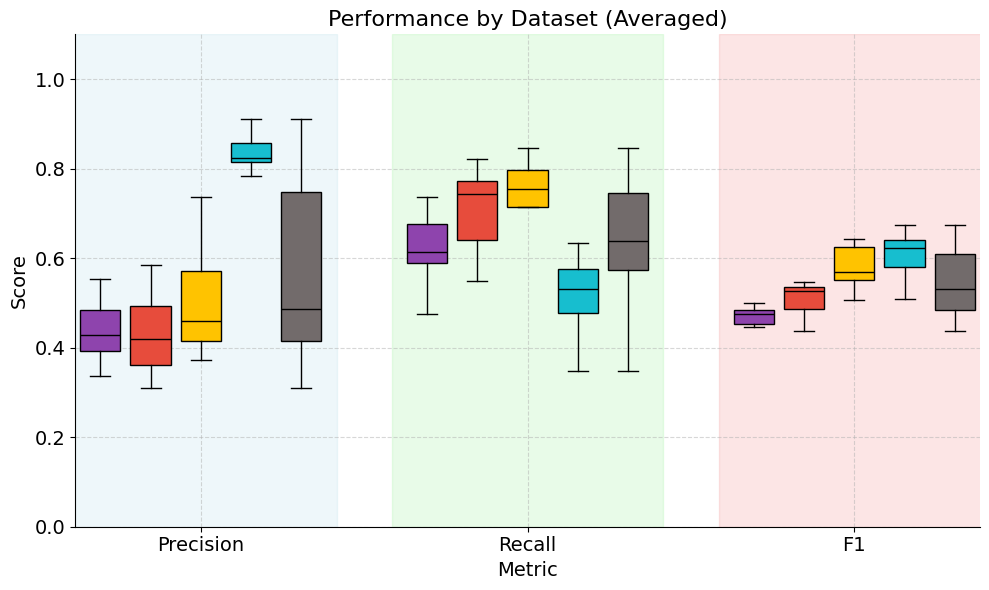

In [ ]:
fig,ax=plot_whiskers_dataset(results_df, metrics=["Precision", "Recall", "F1"],group_level="dataset",colors=dataset_colors,add_overall=True,stat_test=False)
# fig.savefig(os.path.join("figures","whiskers_by_dataset_grouped_2.png"),bbox_inches="tight",dpi=300)

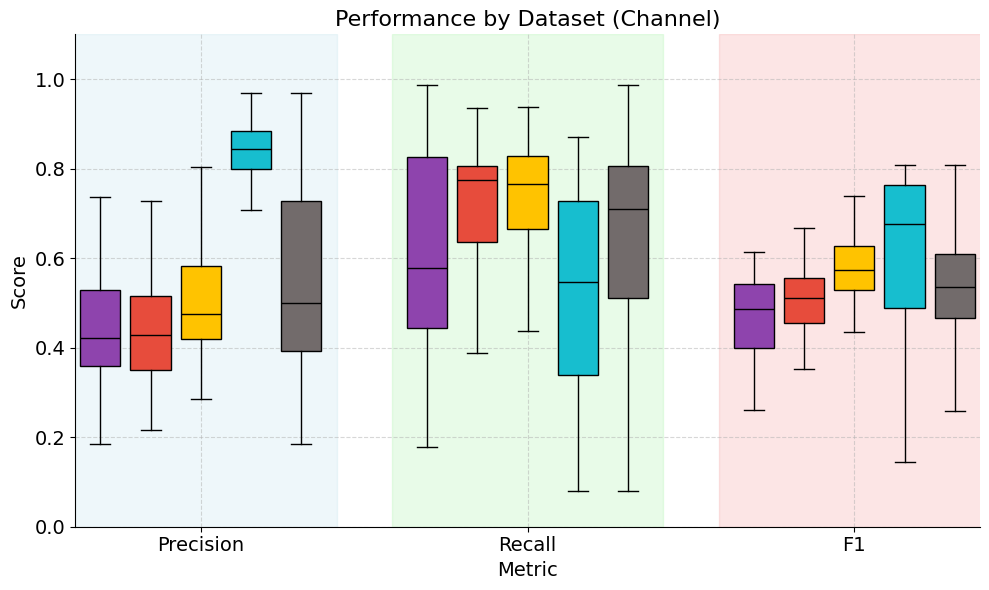

In [16]:
fig,ax=plot_whiskers_dataset(results_df, metrics=["Precision", "Recall", "F1"],group_level="channel",colors=dataset_colors,add_overall=True,stat_test=False)
fig.savefig(os.path.join("figures","whiskers_by_channel_grouped.png"),bbox_inches="tight",dpi=300)

In [66]:
def summarize_metrics_by_dataset_and_network_averaged(df, metrics=["Precision", "Recall", "F1"]):
    summary_rows = []

    # Step 1: Average metrics per (Dataset, Network) → averaging over channels
    dataset_network_means = df.groupby(['Dataset', 'Network'])[metrics].mean().reset_index()

    datasets = sorted(dataset_network_means['Dataset'].unique())

    # Step 2: Summarize per dataset, using network means (averaged over channels)
    for dataset in datasets:
        subset = dataset_network_means[dataset_network_means['Dataset'] == dataset]
        row = {"Dataset": dataset}
        for metric in metrics:
            vals = subset[metric].dropna()
            row[f"{metric} Median ± Std"] = f"{vals.median():.2f} ± {vals.std():.2f}"
            row[f"{metric} Mean"] = f"{vals.mean():.2f}"
            row[f"{metric} Peak"] = f"{vals.max():.2f}"
        summary_rows.append(row)

    # Step 3: Average those means across datasets to get per-network overall means
    network_overall_means = dataset_network_means.groupby('Network')[metrics].mean()

    overall_row = {"Dataset": "Overall"}

    # Step 4: Overall mean, std, median from raw values (all channels, all datasets, all networks)
    for metric in metrics:
        all_vals = df[metric].dropna()
        mean = all_vals.mean()
        std = all_vals.std()
        median = all_vals.median()

        # Step 5: Find best network by highest mean across datasets
        best_network = network_overall_means[metric].idxmax()
        best_network_avg = network_overall_means.loc[best_network, metric]

        overall_row[f"{metric} Median ± Std"] = f"{median:.2f} ± {std:.2f}"
        overall_row[f"{metric} Mean"] = f"{mean:.2f}"
        overall_row[f"{metric} Peak"] = f"{best_network_avg:.2f}"

    summary_rows.append(overall_row)

    summary_df = pd.DataFrame(summary_rows)
    return summary_df

In [67]:
summary_df=summarize_metrics_by_dataset_and_network_averaged(results_df, metrics=["Precision", "Recall", "F1"])
# Save to Excel
output_path = f"figures\\summary_average_network_{identifier}.xlsx"
summary_df.to_excel(output_path, index=False)

In [68]:
import matplotlib.pyplot as plt

def plot_precision_recall_by_dataset(df, dataset_colors):
    list_datasets = sorted(df["Dataset"].unique())
    dataset_labels = {
        list_datasets[0]: "Amigo",
        list_datasets[1]: "Dlx",
        list_datasets[2]: "Som",
        list_datasets[3]: "Thy"
    }

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot each dataset group
    for dataset in sorted(df["Dataset"].unique()):
        group = df[df["Dataset"] == dataset]
        label = dataset_labels.get(dataset, dataset)
        color = dataset_colors.get(label, "gray")
        ax.scatter(
            group["Recall"], group["Precision"],
            label=label, color=color,
            alpha=0.6, s=60, edgecolors='black'
        )

    # Aesthetics
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xlabel("Recall", fontsize=14)
    ax.set_ylabel("Precision", fontsize=14)
    ax.set_title("Precision vs. Recall - Channels", fontsize=16)
    # ax.legend(title="Dataset", title_fontsize=13, fontsize=12,
    #           loc='center left', bbox_to_anchor=(1.01, 0.5))
    ax.grid(True, linestyle='--', alpha=0.6)

    # Optional: remove top/right spines
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    fig.tight_layout()
    return fig, ax


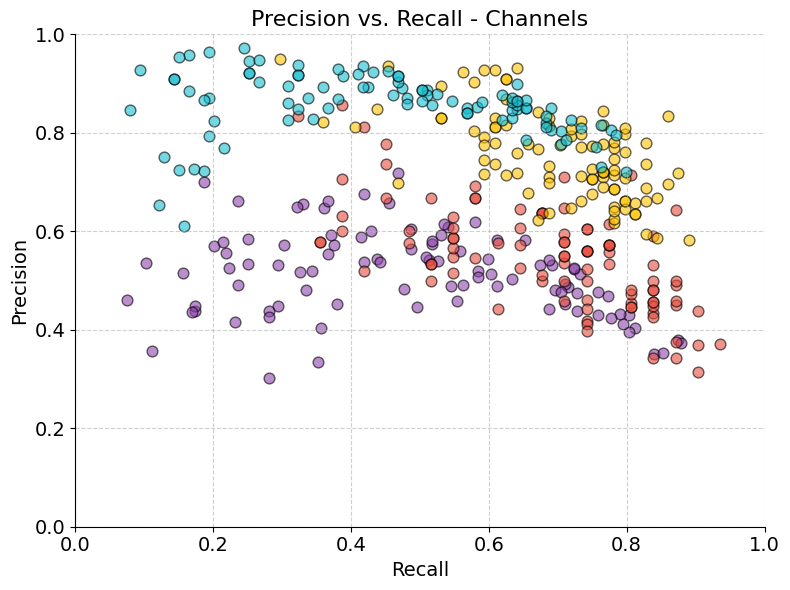

In [69]:
fig,ax=plot_precision_recall_by_dataset(results_df,dataset_colors)
save_path="figures\\precision_recall_by_dataset.png"
fig.savefig(save_path, bbox_inches="tight", dpi=300)

In [70]:
import pandas as pd
from scipy.stats import kruskal

def compare_channels_within_datasets(df, metrics=["Precision", "Recall", "F1"]):
    results = []
    datasets = sorted(df['Dataset'].unique())

    for dataset in datasets:
        subset = df[df['Dataset'] == dataset]
        for metric in metrics:
            # Group values by channel
            channel_groups = [group[metric].dropna().values 
                              for _, group in subset.groupby("Channel")]

            # Only test if we have at least 2 channels with data
            if len(channel_groups) > 1:
                stat, p = kruskal(*channel_groups)
                results.append({
                    "Dataset": dataset,
                    "Metric": metric,
                    "Kruskal-Wallis H": stat,
                    "p-value": p
                })
            else:
                results.append({
                    "Dataset": dataset,
                    "Metric": metric,
                    "Kruskal-Wallis H": None,
                    "p-value": None
                })

    return pd.DataFrame(results)

# Example usage:
channel_diff_results = compare_channels_within_datasets(results_df)
print(channel_diff_results)



                       Dataset     Metric  Kruskal-Wallis H       p-value
0   Amigo2_2019-07-11_11-57-07  Precision         51.162933  8.533879e-09
1   Amigo2_2019-07-11_11-57-07     Recall         77.888358  3.709624e-14
2   Amigo2_2019-07-11_11-57-07         F1         77.951675  3.601140e-14
3     Dlx1_2021-02-12_12-46-54  Precision         16.890690  1.811479e-02
4     Dlx1_2021-02-12_12-46-54     Recall         56.737075  6.741925e-10
5     Dlx1_2021-02-12_12-46-54         F1         28.417717  1.846786e-04
6     Som2_2019-07-24_12-01-49  Precision          5.941098  5.466437e-01
7     Som2_2019-07-24_12-01-49     Recall         43.125854  3.154073e-07
8     Som2_2019-07-24_12-01-49         F1         46.832576  6.017833e-08
9     Thy7_2020-11-11_16-05-00  Precision         35.822314  7.830910e-06
10    Thy7_2020-11-11_16-05-00     Recall         75.094619  1.372056e-13
11    Thy7_2020-11-11_16-05-00         F1         73.743692  2.579574e-13


In [71]:
import pandas as pd
from scipy.stats import f_oneway
def one_way_anova(df, metric):
    datasets = df['Dataset'].unique()
    print("Metric:", metric)
    for dataset in datasets:
        subset = df[df['Dataset'] == dataset]

        # Group metric values by channel
        channel_groups = [subset[subset['Channel'] == ch][metric].dropna().values for ch in subset['Channel'].unique()]

        # Make sure each channel has data
        channel_groups = [g for g in channel_groups if len(g) > 0]

        if len(channel_groups) < 2:
            print(f"Dataset {dataset} does not have enough channels with data for ANOVA.")
            continue

        stat, p = f_oneway(*channel_groups)
   
        print(f"Dataset: {dataset} -- One-way ANOVA F = {stat:.3f}, p = {p:.3e}")
one_way_anova(results_df, "Precision")
one_way_anova(results_df, "Recall")
one_way_anova(results_df, "F1")

Metric: Precision
Dataset: Amigo2_2019-07-11_11-57-07 -- One-way ANOVA F = 12.934, p = 2.492e-11
Dataset: Dlx1_2021-02-12_12-46-54 -- One-way ANOVA F = 2.978, p = 7.504e-03
Dataset: Som2_2019-07-24_12-01-49 -- One-way ANOVA F = 0.952, p = 4.716e-01
Dataset: Thy7_2020-11-11_16-05-00 -- One-way ANOVA F = 7.574, p = 3.954e-07
Metric: Recall
Dataset: Amigo2_2019-07-11_11-57-07 -- One-way ANOVA F = 53.483, p = 5.046e-29
Dataset: Dlx1_2021-02-12_12-46-54 -- One-way ANOVA F = 18.840, p = 3.905e-15
Dataset: Som2_2019-07-24_12-01-49 -- One-way ANOVA F = 10.250, p = 2.489e-09
Dataset: Thy7_2020-11-11_16-05-00 -- One-way ANOVA F = 53.551, p = 4.826e-29
Metric: F1
Dataset: Amigo2_2019-07-11_11-57-07 -- One-way ANOVA F = 53.769, p = 4.183e-29
Dataset: Dlx1_2021-02-12_12-46-54 -- One-way ANOVA F = 5.104, p = 6.745e-05
Dataset: Som2_2019-07-24_12-01-49 -- One-way ANOVA F = 10.866, p = 8.313e-10
Dataset: Thy7_2020-11-11_16-05-00 -- One-way ANOVA F = 67.525, p = 1.155e-32


In [72]:
import pandas as pd
from scipy.stats import f_oneway

def compare_datasets(df, metrics=["Precision", "Recall", "F1"]):
    results = []

    # Step 1: average over channels for each (Network, Dataset)
    df_avg = df.groupby(["Network", "Dataset"])[metrics].mean().reset_index()

    # Step 2: for each metric, run one-way ANOVA across datasets
    datasets = sorted(df_avg["Dataset"].unique())
    for metric in metrics:
        # Collect values for each dataset
        groups = [df_avg.loc[df_avg["Dataset"] == ds, metric].values
                  for ds in datasets]

        stat, pval = f_oneway(*groups)

        results.append({
            "Metric": metric,
            "ANOVA_stat": stat,
            "p_value": pval
        })

    return pd.DataFrame(results)


In [73]:
compare_datasets(results_df, metrics=["Precision", "Recall", "F1"])

,Metric,ANOVA_stat,p_value
0,Precision,70.575356,7.530377e-17
1,Recall,24.656105,1.630172e-09
2,F1,63.450988,5.090717e-16


In [74]:
import pandas as pd
import itertools
from scipy.stats import ttest_ind

def pairwise_dataset_comparison(df, metrics=["Precision", "Recall", "F1"]):
    results = []

    # Step 1: average over channels for each (Network, Dataset)
    df_avg = df.groupby(["Network", "Dataset"])[metrics].mean().reset_index()

    # Step 2: all unique dataset pairs
    datasets = sorted(df_avg["Dataset"].unique())
    pairs = list(itertools.combinations(datasets, 2))
    n_tests = len(pairs) # for Bonferroni correction

    # Step 3: pairwise independent t-tests
    for metric in metrics:
        for ds1, ds2 in pairs:
            vals1 = df_avg.loc[df_avg["Dataset"] == ds1, metric].values
            vals2 = df_avg.loc[df_avg["Dataset"] == ds2, metric].values

            stat, pval = ttest_ind(vals1, vals2, equal_var=False)  # Welch's t-test

            # Bonferroni correction
            pval_adj = min(pval * n_tests, 1.0)

            results.append({
                "Metric": metric,
                "Dataset 1": ds1,
                "Dataset 2": ds2,
                "t_stat": stat,
                "p_value_raw": pval,
                "p_value_adj": pval_adj
            })

    return pd.DataFrame(results)

In [75]:
pairwise_dataset_comparison(results_df)


,Metric,Dataset 1,Dataset 2,t_stat,p_value_raw,p_value_adj
0,Precision,Amigo2_2019-07-11_11-57-07,Dlx1_2021-02-12_12-46-54,-1.214429,2.394493e-01,1.000000e+00
1,Precision,Amigo2_2019-07-11_11-57-07,Som2_2019-07-24_12-01-49,-8.503654,4.948693e-08,2.969216e-07
2,Precision,Amigo2_2019-07-11_11-57-07,Thy7_2020-11-11_16-05-00,-17.689039,3.733183e-13,2.239910e-12
3,Precision,Dlx1_2021-02-12_12-46-54,Som2_2019-07-24_12-01-49,-6.038498,4.540763e-06,2.724458e-05
4,Precision,Dlx1_2021-02-12_12-46-54,Thy7_2020-11-11_16-05-00,-11.398738,1.000952e-08,6.005709e-08
5,Precision,Som2_2019-07-24_12-01-49,Thy7_2020-11-11_16-05-00,-4.005080,1.105094e-03,6.630567e-03
6,Recall,Amigo2_2019-07-11_11-57-07,Dlx1_2021-02-12_12-46-54,-5.075602,4.407765e-05,2.644659e-04
7,Recall,Amigo2_2019-07-11_11-57-07,Som2_2019-07-24_12-01-49,-5.678340,1.079097e-05,6.474583e-05
8,Recall,Amigo2_2019-07-11_11-57-07,Thy7_2020-11-11_16-05-00,1.072503,2.951880e-01,1.000000e+00
9,Recall,Dlx1_2021-02-12_12-46-54,Som2_2019-07-24_12-01-49,-0.458650,6.510028e-01,1.000000e+00
